## 📌 Project Overview

This project focuses on preparing a raw sales dataset for downstream use by performing a data cleaning pipeline.

The primary objective is to transform unclean, inconsistent, and incomplete data into a structured, reliable, and analysis-ready dataset.

The cleaning process includes:

* Identifying and handling missing values
* Removing duplicate records
* Standardizing text fields
* Correcting data types
* Resolving inconsistencies across categorical data
* Handling outliers and invalid entries

This project does not include data analysis or modeling.
Its sole purpose is to ensure high data quality and integrity for future use in analytics, reporting, or machine learning tasks.


## 2. Environment Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import missingno as msno
import os

In [2]:
df = pd.read_csv(
    r"data\Nike_Sales_Uncleaned.csv",
    encoding="utf-8",
    on_bad_lines="warn",
    low_memory=False
)

## 3. Initial Data Inspection
We first examine the structure, data types, and a sample of rows.

In [3]:
print("\nSample of first 5 rows:")
df.head()


Sample of first 5 rows:


,Order_ID,Gender_Category,Product_Line,Product_Name,Size,Units_Sold,MRP,Discount_Applied,Revenue,Order_Date,Sales_Channel,Region,Profit
0,2000,Kids,Training,SuperRep Go,M,NaN,NaN,0.47,0.0,2024-03-09,Online,bengaluru,-770.45
1,2001,Women,Soccer,Tiempo Legend,M,3.0,4957.93,NaN,0.0,2024-07-09,Retail,Hyd,-112.53
2,2002,Women,Soccer,Premier III,M,4.0,NaN,NaN,0.0,NaN,Retail,Mumbai,3337.34
3,2003,Kids,Lifestyle,Blazer Mid,L,NaN,9673.57,NaN,0.0,04-10-2024,Online,Pune,3376.85
4,2004,Kids,Running,React Infinity,XL,NaN,NaN,NaN,0.0,2024/09/12,Retail,Delhi,187.89


In [4]:
print("\nSample of last 5 rows:")
df.tail()


Sample of last 5 rows:


,Order_ID,Gender_Category,Product_Line,Product_Name,Size,Units_Sold,MRP,Discount_Applied,Revenue,Order_Date,Sales_Channel,Region,Profit
2495,4495,Kids,Basketball,Kyrie Flytrap,XL,3.0,NaN,NaN,0.0,2025-05-14,Online,Pune,2.97
2496,4496,Men,Basketball,Kyrie Flytrap,L,-1.0,NaN,NaN,0.0,NaN,Online,Hyd,-487.36
2497,4497,Men,Soccer,Tiempo Legend,7,NaN,6647.60,0.52,0.0,02-07-2025,Retail,Bangalore,-918.14
2498,4498,Women,Training,ZoomX Invincible,NaN,4.0,5358.70,NaN,0.0,11-12-2024,Online,Mumbai,3352.29
2499,4499,Women,Running,Air Zoom,M,NaN,5550.99,NaN,0.0,23-11-2024,Retail,Mumbai,2453.57


In [5]:
df.shape

(2500, 13)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          2500 non-null   int64  
 1   Gender_Category   2500 non-null   object 
 2   Product_Line      2500 non-null   object 
 3   Product_Name      2500 non-null   object 
 4   Size              1990 non-null   object 
 5   Units_Sold        1265 non-null   float64
 6   MRP               1246 non-null   float64
 7   Discount_Applied  832 non-null    float64
 8   Revenue           2500 non-null   float64
 9   Order_Date        1884 non-null   object 
 10  Sales_Channel     2500 non-null   object 
 11  Region            2500 non-null   object 
 12  Profit            2500 non-null   float64
dtypes: float64(5), int64(1), object(7)
memory usage: 254.0+ KB


## Missing Data Visualization — BEFORE Cleaning

<Figure size 1200x600 with 0 Axes>

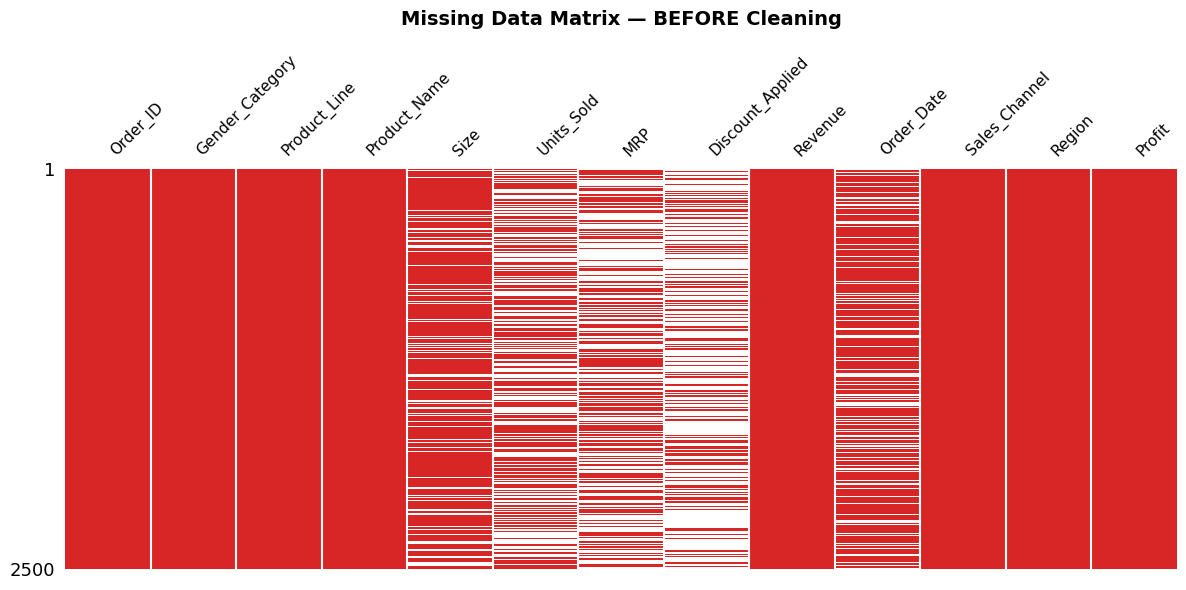

In [7]:
plt.figure(figsize=(12, 6))
msno.matrix(df, figsize=(12, 6), fontsize=11, sparkline=False, color=(0.85, 0.15, 0.15))
plt.title("Missing Data Matrix — BEFORE Cleaning", fontsize=14, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()


## 4. Data Quality Assessment

This step identifies all quality issues **before** any modification.

We investigate the following dimensions:
- **Completeness** – Missing values per column (count & %)
- **Uniqueness** – Duplicate rows
- **Validity** – Invalid ranges (negative units, discounts > 100%)
- **Consistency** – Revenue vs. recalculated revenue; Profit vs. Revenue logic
- **Uniformity** – Date format fragmentation, Region spelling inconsistencies


In [8]:
# 1 — Missing values (counts + %)
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(1)

missing_df = (
    pd.DataFrame({
        "Missing_Count": missing,
        "Percentage": missing_pct
    })
    .query("Missing_Count > 0")
    .sort_values("Percentage", ascending=False)
)

print("\nMISSING VALUES:\n")
display(missing_df)


MISSING VALUES:



,Missing_Count,Percentage
Discount_Applied,1668,66.7
MRP,1254,50.2
Units_Sold,1235,49.4
Order_Date,616,24.6
Size,510,20.4


In [9]:
# 2 — Duplicate rows
duplicates = df.duplicated().sum()
print(f"\nDUPLICATES: {duplicates} duplicate rows")


DUPLICATES: 0 duplicate rows


In [10]:
# 3 — Core data anomalies (units, revenue, profit)
negative_units = (df["Units_Sold"] < 0).sum()
zero_units = (df["Units_Sold"] == 0).sum()
zero_revenue = (df["Revenue"] == 0).sum()
negative_profit = (df["Profit"] < 0).sum()

print("\nDATA ANOMALIES:")
print(f"   Negative Units_Sold (returns): {negative_units}")
print(f"   Zero Units_Sold: {zero_units}")
print(f"   Zero Revenue records: {zero_revenue}")
print(f"   Negative Profit records: {negative_profit}")


DATA ANOMALIES:
   Negative Units_Sold (returns): 205
   Zero Units_Sold: 224
   Zero Revenue records: 2334
   Negative Profit records: 578


In [11]:
# 4 — Revenue reconstruction check (NO mutation; diagnostic only)
revenue_recalc = (
    df["Units_Sold"] *
    df["MRP"] *
    (1 - df["Discount_Applied"])
)

comparison = pd.DataFrame({
    "Revenue_actual": df["Revenue"],
    "Revenue_recalc": revenue_recalc
})

display(comparison.head(10))

,Revenue_actual,Revenue_recalc
0,0.0,NaN
1,0.0,NaN
2,0.0,NaN
3,0.0,NaN
4,0.0,NaN
5,0.0,NaN
6,0.0,NaN
7,0.0,NaN
8,0.0,NaN
9,0.0,NaN


In [12]:
# 5 — Revenue mismatch + validation coverage
# Note: mismatch evaluated only where Revenue_recalc is not null
valid_mask = comparison["Revenue_recalc"].notna()

mismatch = (
    (comparison.loc[valid_mask, "Revenue_actual"] - comparison.loc[valid_mask, "Revenue_recalc"])
    .abs() > 1
).sum()

valid_rows = valid_mask.sum()
coverage_pct = round(valid_rows / len(df) * 100, 2)

print("Revenue mismatch rows (within valid subset):", mismatch)
print("Rows where revenue could be validated:", valid_rows)
print("Validation coverage %:", coverage_pct)

Revenue mismatch rows (within valid subset): 0
Rows where revenue could be validated: 207
Validation coverage %: 8.28


In [13]:
# 6 — Zero-revenue distribution by Sales_Channel & Product_Line
zero_rev_profile = (
    df[df["Revenue"] == 0]
    .groupby(["Sales_Channel", "Product_Line"])
    .size()
    .sort_values(ascending=False)
)

display(zero_rev_profile.head(10))

Sales_Channel  Product_Line
Online         Training        261
Retail         Training        244
               Basketball      241
Online         Lifestyle       238
Retail         Lifestyle       232
Online         Basketball      231
               Running         229
Retail         Running         223
Online         Soccer          219
Retail         Soccer          216
dtype: int64

In [14]:
# 7 — Profit inconsistency check (Revenue == 0 but Profit != 0)
inconsistent_profit = df[(df["Revenue"] == 0) & (df["Profit"] != 0)]
print("Inconsistent profit rows:", len(inconsistent_profit))

Inconsistent profit rows: 2334


In [15]:
# 8 — Missingness correlation (do missing values co-occur?)
missing_corr = df[["Units_Sold", "MRP", "Discount_Applied"]].isna().corr()
display(missing_corr)

,Units_Sold,MRP,Discount_Applied
Units_Sold,1.000000,0.004039,0.032273
MRP,0.004039,1.000000,-0.033393
Discount_Applied,0.032273,-0.033393,1.000000


In [16]:
# 9 — Missingness by Product_Line (imputation should be group-aware?)
missing_by_product = (
    df.groupby("Product_Line")[["Units_Sold", "MRP", "Discount_Applied"]]
    .apply(lambda x: x.isna().mean())
)

display(missing_by_product)

,Units_Sold,MRP,Discount_Applied
Product_Line,,,
Basketball,0.520710,0.481262,0.648915
Lifestyle,0.487026,0.475050,0.686627
Running,0.521097,0.491561,0.670886
Soccer,0.455508,0.538136,0.669492
Training,0.485348,0.521978,0.661172


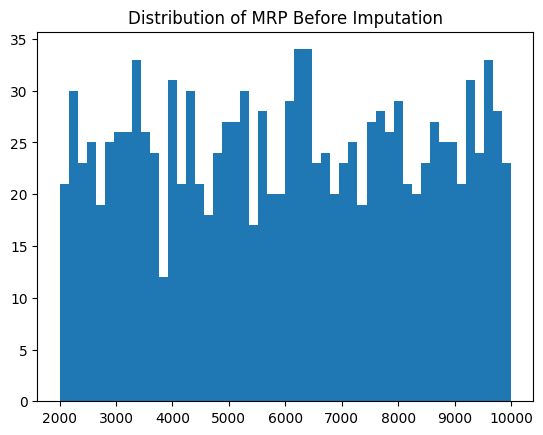

In [17]:
# Quick look at MRP distribution
plt.hist(df['MRP'].dropna(), bins=50)
plt.title("Distribution of MRP Before Imputation")
plt.show()


### Discount Validity Check

In [18]:
# 10 — Discount issues
invalid_discounts = (df["Discount_Applied"] > 1).sum()
negative_discounts = (df["Discount_Applied"] < 0).sum()
high_discounts = (df["Discount_Applied"] > 0.9).sum()

print("\nDISCOUNT ANALYSIS:")
print(f"   Discounts > 100% (likely data entry errors): {invalid_discounts}")
if invalid_discounts > 0:
    print("   Sample invalid values:", df.loc[df["Discount_Applied"] > 1, "Discount_Applied"].head().tolist())

print("   Negative discounts:", negative_discounts)
print("   High discounts (>0.9):", high_discounts)


DISCOUNT ANALYSIS:
   Discounts > 100% (likely data entry errors): 180
   Sample invalid values: [1.17, 1.05, 1.07, 1.01, 1.04]
   Negative discounts: 0
   High discounts (>0.9): 237


### Date Format Inspection

In [19]:
# 11 — Date formats & ambiguity risk (no parsing yet)
sample_dates = df["Order_Date"].head(5).tolist()
print("\nDATE FORMAT:")
print("   Sample dates:", sample_dates)
print("   ⚠️ Mixed formats detected – will be standardized later (with explicit assumptions).")

ambiguous_dates = df["Order_Date"].dropna().astype(str).str.match(r"^\d{2}-\d{2}-\d{4}$").sum()
print("Potential DD/MM ambiguity rows:", ambiguous_dates)

date_patterns = df["Order_Date"].dropna().astype(str).str.extract(
    r"(^\d{4}[-/]\d{2}[-/]\d{2}$)|(^\d{2}-\d{2}-\d{4}$)"
)
print("Potential mixed formats detected:")
print(date_patterns.notna().sum())


DATE FORMAT:
   Sample dates: ['2024-03-09', '2024-07-09', nan, '04-10-2024', '2024/09/12']
   ⚠️ Mixed formats detected – will be standardized later (with explicit assumptions).
Potential DD/MM ambiguity rows: 668
Potential mixed formats detected:
0    1216
1     668
dtype: int64


### Categorical Consistency & Region Fragmentation

In [20]:
# 12 — Categorical values (uniques) + Region fragmentation
print("\nUnique values in categorical columns:")
print("- Gender_Category:", df["Gender_Category"].unique())
print("- Product_Line:", df["Product_Line"].unique())
print("- Sales_Channel:", df["Sales_Channel"].unique())
print("- Region:", df["Region"].unique())
print("- Size:", df["Size"].unique())

print("\nRegion value counts (to spot fragmentation):")
display(df["Region"].value_counts())


Unique values in categorical columns:
- Gender_Category: ['Kids' 'Women' 'Men']
- Product_Line: ['Training' 'Soccer' 'Lifestyle' 'Running' 'Basketball']
- Sales_Channel: ['Online' 'Retail']
- Region: ['bengaluru' 'Hyd' 'Mumbai' 'Pune' 'Delhi' 'Bangalore' 'Hyderabad'
 'hyderbad' 'Kolkata']
- Size: ['M' 'L' 'XL' '11' nan '9' '6' '12' '7' '10' '8']

Region value counts (to spot fragmentation):


Region
Delhi        438
Mumbai       418
Kolkata      417
Pune         388
bengaluru    220
Bangalore    216
hyderbad     141
Hyd          136
Hyderabad    126
Name: count, dtype: int64

### Hidden Whitespace Detection

In [21]:
# Check for hidden whitespaces in string columns
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    original_uniques = df[col].nunique()
    stripped_uniques = df[col].dropna().astype(str).str.strip().nunique()
    if original_uniques != stripped_uniques:
        print(f"⚠️ Column '{col}' has hidden whitespaces!")


### Numeric Distribution Summary

In [22]:
# 13 — Numeric summary
print("\nNUMERIC COLUMNS SUMMARY:")
display(df[["Units_Sold", "MRP", "Discount_Applied", "Revenue", "Profit"]].describe())


NUMERIC COLUMNS SUMMARY:


,Units_Sold,MRP,Discount_Applied,Revenue,Profit
count,1265.000000,1246.000000,832.000000,2500.000000,2500.000000
mean,1.482213,6039.863395,0.631022,274.873716,1376.012848
std,1.696947,2315.746826,0.365500,2023.773550,1478.671013
min,-1.000000,2006.630000,0.000000,-7561.590000,-1199.450000
25%,0.000000,4038.902500,0.320000,0.000000,93.532500
50%,2.000000,6110.030000,0.615000,0.000000,1371.385000
75%,3.000000,8022.187500,0.962500,0.000000,2660.645000
max,4.000000,9996.220000,1.250000,37169.350000,3999.210000


## 5. Data Cleaning

We fix structural errors **before** any imputation to avoid propagating garbage.


In [23]:
# Keep immutable raw snapshot
df_raw = df.copy()
df_clean = df.copy()
df_clean = df_clean.drop_duplicates()

# Config
MAX_ALLOWED_DISCOUNT = 1.0

print("Starting rows:", len(df_clean))

Starting rows: 2500


In [24]:
# 2 — Flag returns (DO NOT delete yet)
df_clean["is_return"] = df_clean["Units_Sold"].lt(0).fillna(False)

print("Return rows flagged:", df_clean["is_return"].sum())

Return rows flagged: 205


In [25]:
# 3 — Conditional discount repair (evidence-based)
""" Discounts in the range [1.0, 1.3] follow a systematic +1 offset pattern and
    are corrected by subtracting 1. """ 

# Identify offset pattern candidates (tight band above 1)
offset_mask = df_clean["Discount_Applied"].between(1.0, 1.3)

print("Offset candidates:", offset_mask.sum())

# Apply correction only where evidence supports it
df_clean.loc[offset_mask, "Discount_Applied"] = (
    df_clean.loc[offset_mask, "Discount_Applied"] - 1
)

# Any remaining invalid discounts → set to NaN (structural fix)
remaining_invalid = (
    (df_clean["Discount_Applied"] < 0) |
    (df_clean["Discount_Applied"] > MAX_ALLOWED_DISCOUNT)
)

print("Remaining invalid discounts:", remaining_invalid.sum())
df_clean.loc[remaining_invalid, "Discount_Applied"] = np.nan

Offset candidates: 187
Remaining invalid discounts: 0


In [26]:
# 4 — Date standardization (robust, audit-safe, warning-free)
# Order_Date_raw preserved for audit purposes only
# Missing count (616) matches original missing — intentionally left as NaN

# --- Preserve raw values ---
df_clean["Order_Date_raw"] = df_clean["Order_Date"]

# --- Normalize to clean string ---
date_str = (
    df_clean["Order_Date"]
    .astype("string")
    .str.strip()
)

# Treat literal "nan"/"None" strings as missing
date_str = date_str.replace({"nan": pd.NA, "None": pd.NA})

# --- Initialize parsed container ---
parsed_dates = pd.Series(pd.NaT, index=df_clean.index)

# =========================================================
# 1️⃣ ISO formats: YYYY-MM-DD or YYYY/MM/DD
# =========================================================
iso_mask = date_str.str.match(r"^\d{4}[-/]\d{2}[-/]\d{2}$", na=False)

parsed_dates.loc[iso_mask] = pd.to_datetime(
    date_str.loc[iso_mask],
    errors="coerce"
)

# =========================================================
# 2️⃣ Explicit DD-MM-YYYY (day-first)
# =========================================================
dmy_mask = date_str.str.match(r"^\d{2}-\d{2}-\d{4}$", na=False)

parsed_dates.loc[dmy_mask] = pd.to_datetime(
    date_str.loc[dmy_mask],
    dayfirst=True,
    errors="coerce"
)

# =========================================================
# 3️⃣ Final fallback (only for still-unparsed non-null strings)
# =========================================================
remaining_mask = parsed_dates.isna() & date_str.notna()

parsed_dates.loc[remaining_mask] = pd.to_datetime(
    date_str.loc[remaining_mask],
    errors="coerce"
)

# --- Assign back ---
df_clean["Order_Date"] = parsed_dates

# =========================================================
# Diagnostics (senior-grade)
# =========================================================
print("Parsed ISO:", parsed_dates.loc[iso_mask].notna().sum())
print("Parsed DD-MM-YYYY:", parsed_dates.loc[dmy_mask].notna().sum())
print("Parsed via fallback:", parsed_dates.loc[remaining_mask].notna().sum())
print("Still unparsed (true missing):", parsed_dates.isna().sum())

Parsed ISO: 1216
Parsed DD-MM-YYYY: 668
Parsed via fallback: 616
Still unparsed (true missing): 616


In [27]:
# 5 — Region normalization (structural categorical fix)

region_corrections = {
    "Hyd": "Hyderabad",
    "hyderbad": "Hyderabad",
    "Hyderbad": "Hyderabad",
    "bengaluru": "Bangalore"
}
df_clean["Region"] = df_clean["Region"].str.strip()
df_clean["Region"] = df_clean["Region"].replace(region_corrections)

print("Unique regions:", df_clean["Region"].nunique())
display(df_clean["Region"].value_counts())

Unique regions: 6


Region
Delhi        438
Bangalore    436
Mumbai       418
Kolkata      417
Hyderabad    403
Pune         388
Name: count, dtype: int64

In [28]:
# 6 — Size normalization (SAFE: keep as categorical text)

# Do NOT coerce to numeric — mixed apparel + shoe sizes
df_clean["Size"] = (
    df_clean["Size"]
    .astype("string")
    .str.strip()
)

print("Unique Size values (sample):")
display(df_clean["Size"].dropna().unique()[:15])

Unique Size values (sample):


<StringArray>
['M', 'L', 'XL', '11', '9', '6', '12', '7', '10', '8']
Length: 10, dtype: string

In [29]:
# 7 — Post-clean structural audit

print("\n✅ Rows after structural cleaning:", len(df_clean))

new_cols = [c for c in df_clean.columns if c not in df.columns]
print("New columns added:", new_cols)

print("\nRemaining invalid discounts (>1):",
      (df_clean["Discount_Applied"] > 1).sum())

print("Remaining negative discounts:",
      (df_clean["Discount_Applied"] < 0).sum())

print("Remaining unparsed dates:",
      df_clean["Order_Date"].isna().sum())


✅ Rows after structural cleaning: 2500
New columns added: ['is_return', 'Order_Date_raw']

Remaining invalid discounts (>1): 0
Remaining negative discounts: 0
Remaining unparsed dates: 616


In [30]:
df_clean.head(10)

,Order_ID,Gender_Category,Product_Line,Product_Name,Size,Units_Sold,MRP,Discount_Applied,Revenue,Order_Date,Sales_Channel,Region,Profit,is_return,Order_Date_raw
0,2000,Kids,Training,SuperRep Go,M,NaN,NaN,0.47,0.0,2024-03-09,Online,Bangalore,-770.45,False,2024-03-09
1,2001,Women,Soccer,Tiempo Legend,M,3.0,4957.93,NaN,0.0,2024-07-09,Retail,Hyderabad,-112.53,False,2024-07-09
2,2002,Women,Soccer,Premier III,M,4.0,NaN,NaN,0.0,NaT,Retail,Mumbai,3337.34,False,NaN
3,2003,Kids,Lifestyle,Blazer Mid,L,NaN,9673.57,NaN,0.0,2024-10-04,Online,Pune,3376.85,False,04-10-2024
4,2004,Kids,Running,React Infinity,XL,NaN,NaN,NaN,0.0,2024-09-12,Retail,Delhi,187.89,False,2024/09/12
5,2005,Women,Training,Flex Trainer,M,1.0,7363.96,NaN,0.0,NaT,Retail,Delhi,1415.98,False,NaN
6,2006,Men,Training,SuperRep Go,M,NaN,6819.78,NaN,0.0,2025-06-04,Online,Bangalore,1802.09,False,04-06-2025
7,2007,Kids,Training,SuperRep Go,M,1.0,NaN,0.32,0.0,NaT,Retail,Bangalore,2928.36,False,NaN
8,2008,Women,Soccer,Premier III,11,-1.0,NaN,NaN,0.0,2024-10-11,Online,Hyderabad,-731.18,True,11-10-2024
9,2009,Men,Soccer,Mercurial Superfly,M,4.0,NaN,NaN,0.0,NaT,Online,Pune,3929.61,False,NaN


In [31]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_ID          2500 non-null   int64         
 1   Gender_Category   2500 non-null   object        
 2   Product_Line      2500 non-null   object        
 3   Product_Name      2500 non-null   object        
 4   Size              1990 non-null   string        
 5   Units_Sold        1265 non-null   float64       
 6   MRP               1246 non-null   float64       
 7   Discount_Applied  832 non-null    float64       
 8   Revenue           2500 non-null   float64       
 9   Order_Date        1884 non-null   datetime64[ns]
 10  Sales_Channel     2500 non-null   object        
 11  Region            2500 non-null   object        
 12  Profit            2500 non-null   float64       
 13  is_return         2500 non-null   bool          
 14  Order_Date_raw    1884 n

In [32]:
# Region normalization impact
print("Before:", df_raw["Region"].nunique(), "unique regions")
print("After:", df_clean["Region"].nunique(), "unique regions")
print("Rows corrected:", (df_raw["Region"] != df_clean["Region"]).sum())

Before: 9 unique regions
After: 6 unique regions
Rows corrected: 497


In [33]:
# Sanity check — ensure no rows were lost during structural cleaning
assert len(df_clean) == len(df_raw), "❌ Rows were lost during cleaning!"
print(f"✅ Row count preserved: {len(df_clean):,} rows")


✅ Row count preserved: 2,500 rows


### ✅ Structural Cleaning Summary
All structural fixes applied with zero row deletions:
- Returns flagged (`is_return`)
- Discounts corrected or nullified
- Dates unified to `datetime64`
- Regions consolidated from 9 → 6
- Row count preserved: **2,500 rows**


## 6. Advanced Imputation Strategy

Hybrid approach: deterministic recovery → statistical imputation → conservative fallbacks.
Revenue policy: use raw if valid else calculated."

In [34]:
ZERO_REVENUE_THRESHOLD = 0.01
REVENUE_MATCH_TOLERANCE = 1.0 # max acceptable gap (in currency) between raw and calculated Revenue

print("Rows:", len(df_clean))

# --- Preserve raw columns for auditability
df_clean["Units_Sold_raw"] = df_clean["Units_Sold"]
df_clean["MRP_raw"] = df_clean["MRP"]
df_clean["Discount_Applied_raw"] = df_clean["Discount_Applied"]
df_clean["Revenue_raw"] = df_clean["Revenue"]
df_clean["Profit_raw"] = df_clean["Profit"]

Rows: 2500


In [35]:
# --- Transparent flags (dashboard & audit friendly)

df_clean["Units_Recovered_Flag"] = False
df_clean["MRP_Recovered_Flag"] = False
df_clean["MRP_Imputed_Flag"] = False
df_clean["Units_Imputed_Baseline_Flag"] = False
df_clean["Discount_Imputed_Flag"] = False
df_clean["Size_Imputed_Flag"] = False
df_clean["Revenue_Used_Calc_Flag"] = False

In [36]:
print("\n📐 Step 1: Mathematical Recovery")

# --- Recover Units_Sold from Revenue_raw / MRP
mask_recover_units = (
    df_clean["Units_Sold"].isna() &
    df_clean["Revenue_raw"].notna() &
    (df_clean["Revenue_raw"].abs() > ZERO_REVENUE_THRESHOLD) &
    df_clean["MRP"].notna() &
    (df_clean["MRP"] > 0)
)

df_clean.loc[mask_recover_units, "Units_Sold"] = (
    df_clean.loc[mask_recover_units, "Revenue_raw"] /
    df_clean.loc[mask_recover_units, "MRP"]
)

df_clean.loc[mask_recover_units, "Units_Recovered_Flag"] = True
print(f"   ✓ Recovered {mask_recover_units.sum()} Units_Sold values")

# --- Recover MRP from Revenue_raw / Units_Sold
mask_recover_mrp = (
    df_clean["MRP"].isna() &
    df_clean["Revenue_raw"].notna() &
    (df_clean["Revenue_raw"].abs() > ZERO_REVENUE_THRESHOLD) &
    df_clean["Units_Sold"].notna() &
    (df_clean["Units_Sold"] > 0)
)

df_clean.loc[mask_recover_mrp, "MRP"] = (
    df_clean.loc[mask_recover_mrp, "Revenue_raw"] /
    df_clean.loc[mask_recover_mrp, "Units_Sold"]
)

df_clean.loc[mask_recover_mrp, "MRP_Recovered_Flag"] = True
print(f"   ✓ Recovered {mask_recover_mrp.sum()} MRP values")


📐 Step 1: Mathematical Recovery
   ✓ Recovered 0 Units_Sold values
   ✓ Recovered 0 MRP values


In [37]:
print("\n📊 Step 2: Statistical Imputation (MRP)")

mrp_missing_before = df_clean["MRP"].isna().sum()

# Product-level median
df_clean["MRP"] = df_clean.groupby("Product_Name")["MRP"].transform(
    lambda x: x.fillna(x.median())
)

# Product-line fallback
df_clean["MRP"] = df_clean.groupby("Product_Line")["MRP"].transform(
    lambda x: x.fillna(x.median())
)

# Global fallback
global_mrp_median = df_clean["MRP"].median()
df_clean["MRP"] = df_clean["MRP"].fillna(global_mrp_median)

mrp_missing_after = df_clean["MRP"].isna().sum()

df_clean.loc[
    df_clean["MRP_raw"].isna() & df_clean["MRP"].notna(),
    "MRP_Imputed_Flag"
] = True

print(f"   ✓ MRP missing before: {mrp_missing_before}")
print(f"   ✓ MRP missing after: {mrp_missing_after}")


📊 Step 2: Statistical Imputation (MRP)
   ✓ MRP missing before: 1254
   ✓ MRP missing after: 0


In [38]:
print("\n⚠️ Step 3: Units_Sold Imputation (Group-Median)")

units_missing_before = df_clean["Units_Sold"].isna().sum()

# --- Phase A: Evidence-based fill (Revenue > 0 proves at least 1 unit was sold)
mask_baseline = (
    df_clean["Units_Sold"].isna() &
    df_clean["Revenue_raw"].notna() &
    (df_clean["Revenue_raw"].abs() > ZERO_REVENUE_THRESHOLD)
)
df_clean.loc[mask_baseline, "Units_Sold"] = 1
df_clean.loc[mask_baseline, "Units_Imputed_Baseline_Flag"] = True

# --- Phase B: Group-based median imputation (same methodology as MRP/Discount)
#     Uses median from POSITIVE sales only (excludes returns)
positive_units = df_clean["Units_Sold"].where(df_clean["Units_Sold"] > 0)

# Product-level median
product_medians = positive_units.groupby(df_clean["Product_Name"]).transform("median")
df_clean["Units_Sold"] = df_clean["Units_Sold"].fillna(product_medians)

# Product-line fallback
line_medians = df_clean["Units_Sold"].where(df_clean["Units_Sold"] > 0).groupby(df_clean["Product_Line"]).transform("median")
df_clean["Units_Sold"] = df_clean["Units_Sold"].fillna(line_medians)

# Global fallback
global_units_median = df_clean.loc[df_clean["Units_Sold"] > 0, "Units_Sold"].median()
df_clean["Units_Sold"] = df_clean["Units_Sold"].fillna(global_units_median)

# --- Round to whole numbers (can't sell 0.5 units)
#     Only round imputed rows — keep original negative returns as-is
imputed_mask = df_clean["Units_Sold_raw"].isna()
df_clean.loc[imputed_mask, "Units_Sold"] = df_clean.loc[imputed_mask, "Units_Sold"].round(0)

# --- Flag: marks all rows where Units_Sold was originally missing
df_clean["Units_Sold_Imputed_Flag"] = imputed_mask

units_missing_after = df_clean["Units_Sold"].isna().sum()
units_imputed_total = df_clean["Units_Sold_Imputed_Flag"].sum()

print(f"   ✓ Units missing before: {units_missing_before}")
print(f"   ✓ Units set to baseline=1 (revenue evidence): {mask_baseline.sum()}")
print(f"   ✓ Units imputed via group median: {units_imputed_total - mask_baseline.sum()}")
print(f"   ✓ Units missing after: {units_missing_after}")
print(f"   ✓ Median value used (global fallback): {global_units_median}")



⚠️ Step 3: Units_Sold Imputation (Group-Median)
   ✓ Units missing before: 1235
   ✓ Units set to baseline=1 (revenue evidence): 0
   ✓ Units imputed via group median: 1235
   ✓ Units missing after: 0
   ✓ Median value used (global fallback): 2.0


In [39]:
# Convert to integer (no fractional units possible)
df_clean["Units_Sold"] = df_clean["Units_Sold"].astype(int)
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 28 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Order_ID                     2500 non-null   int64         
 1   Gender_Category              2500 non-null   object        
 2   Product_Line                 2500 non-null   object        
 3   Product_Name                 2500 non-null   object        
 4   Size                         1990 non-null   string        
 5   Units_Sold                   2500 non-null   int64         
 6   MRP                          2500 non-null   float64       
 7   Discount_Applied             832 non-null    float64       
 8   Revenue                      2500 non-null   float64       
 9   Order_Date                   1884 non-null   datetime64[ns]
 10  Sales_Channel                2500 non-null   object        
 11  Region                       2500 non-null 

In [40]:
print("\n🏷️ Step 4: Discount Imputation")

discount_missing_before = df_clean["Discount_Applied"].isna().sum()

df_clean["Discount_Applied"] = df_clean.groupby("Product_Name")["Discount_Applied"].transform(
    lambda x: x.fillna(x.median())
)

df_clean["Discount_Applied"] = df_clean.groupby("Product_Line")["Discount_Applied"].transform(
    lambda x: x.fillna(x.median())
)

df_clean["Discount_Applied"] = df_clean.groupby("Sales_Channel")["Discount_Applied"].transform(
    lambda x: x.fillna(x.median())
)

global_disc_median = df_clean["Discount_Applied"].median()
df_clean["Discount_Applied"] = df_clean["Discount_Applied"].fillna(global_disc_median)

# Safety clamp
df_clean["Discount_Applied"] = df_clean["Discount_Applied"].clip(0, 1)

df_clean.loc[
    df_clean["Discount_Applied_raw"].isna() & df_clean["Discount_Applied"].notna(),
    "Discount_Imputed_Flag"
] = True

print(f"   ✓ Discount missing before: {discount_missing_before}")
print(f"   ✓ Discount missing after: {df_clean['Discount_Applied'].isna().sum()}")


🏷️ Step 4: Discount Imputation
   ✓ Discount missing before: 1668
   ✓ Discount missing after: 0


In [41]:
print("\n📏 Step 5: Size Imputation")

size_missing_before = df_clean["Size"].isna().sum()

df_clean["Size"] = df_clean.groupby("Product_Name")["Size"].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else pd.NA)
)

df_clean["Size"] = df_clean.groupby(["Gender_Category", "Product_Line"])["Size"].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else pd.NA)
)

global_size_mode = (
    df_clean["Size"].mode().iloc[0]
    if not df_clean["Size"].mode().empty
    else pd.NA
)

df_clean["Size"] = df_clean["Size"].fillna(global_size_mode)

# ✅ Correct flagging — mark only rows that were originally missing
df_clean.loc[
    df_raw["Size"].isna() & df_clean["Size"].notna(),
    "Size_Imputed_Flag"
] = True

print(f"   ✓ Size missing before: {size_missing_before}")
print(f"   ✓ Size missing after: {df_clean['Size'].isna().sum()}")
print(f"   ✓ Size imputed rows flagged: {df_clean['Size_Imputed_Flag'].sum()}")



📏 Step 5: Size Imputation
   ✓ Size missing before: 510
   ✓ Size missing after: 0
   ✓ Size imputed rows flagged: 510


In [42]:
print("\n🧮 Step 6: Revenue_calc")

df_clean["Revenue_calc"] = (
    df_clean["Units_Sold"] *
    df_clean["MRP"] *
    (1 - df_clean["Discount_Applied"])
)

# ✅ Diagnostics
print(f"   ✓ Revenue_calc computed for all rows: {df_clean['Revenue_calc'].notna().sum()}")
print(f"   ✓ Revenue_calc nulls: {df_clean['Revenue_calc'].isna().sum()}")
print(f"   ✓ Positive Revenue_calc: {(df_clean['Revenue_calc'] > 0).sum()}")
print(f"   ✓ Zero Revenue_calc: {(df_clean['Revenue_calc'] == 0).sum()}")
print(f"   ✓ Negative Revenue_calc: {(df_clean['Revenue_calc'] < 0).sum()}")



🧮 Step 6: Revenue_calc
   ✓ Revenue_calc computed for all rows: 2500
   ✓ Revenue_calc nulls: 0
   ✓ Positive Revenue_calc: 2071
   ✓ Zero Revenue_calc: 224
   ✓ Negative Revenue_calc: 205


In [43]:
print("\n🔒 Step 7: Revenue_final rule (FIXED)")

calc_meaningful = df_clean["Revenue_calc"].abs() > ZERO_REVENUE_THRESHOLD

# 🚨 CRITICAL FIX — always trust meaningful negative raw revenue
raw_negative = df_clean["Revenue_raw"] < -ZERO_REVENUE_THRESHOLD

raw_valid = (
    raw_negative |
    (
        df_clean["Revenue_raw"].notna() &
        (df_clean["Revenue_raw"].abs() > ZERO_REVENUE_THRESHOLD) &
        (
            ~calc_meaningful |
            ((df_clean["Revenue_raw"] - df_clean["Revenue_calc"]).abs() <= REVENUE_MATCH_TOLERANCE)

        )
    )
)

df_clean["Revenue_final"] = np.where(
    raw_valid,
    df_clean["Revenue_raw"],
    df_clean["Revenue_calc"]
)

df_clean["Revenue_Used_Calc_Flag"] = ~raw_valid

print("Revenue_final uses calc:", df_clean["Revenue_Used_Calc_Flag"].sum())


🔒 Step 7: Revenue_final rule (FIXED)
Revenue_final uses calc: 2337


In [44]:
print("🧪 CHECK — Negative revenue preservation")

neg_raw = (df_clean["Revenue_raw"] < 0).sum()

neg_preserved_rate = (
    (df_clean.loc[df_clean["Revenue_raw"] < 0, "Revenue_final"] < 0)
    .mean()
    if neg_raw > 0 else None
)

print("Negative raw revenue rows:", neg_raw)
print("Preserved as negative in Revenue_final (rate):", neg_preserved_rate)

# Show any violations: raw negative but final not negative
violations = df_clean.loc[
    (df_clean["Revenue_raw"] < 0) & (df_clean["Revenue_final"] >= 0),
    ["Order_ID", "Revenue_raw", "Revenue_calc", "Revenue_final", "is_return"]
]

print("Violations (count):", len(violations))
display(violations.head(10))

🧪 CHECK — Negative revenue preservation
Negative raw revenue rows: 53
Preserved as negative in Revenue_final (rate): 1.0
Violations (count): 0


,Order_ID,Revenue_raw,Revenue_calc,Revenue_final,is_return


In [45]:
df_clean["Is_Zero_Sales"] = (
    (df_clean["Units_Sold"] == 0) &
    (df_clean["MRP"] > 0)
)

print("⚠️ Flagged Is_Zero_Sales rows:", df_clean["Is_Zero_Sales"].sum())

⚠️ Flagged Is_Zero_Sales rows: 224


In [46]:
print("\n📅 Step 8: Missing Order_Date flag")

df_clean["Date_Missing_Flag"] = df_clean["Order_Date"].isna()

print("   ✓ Date_Missing_Flag count:", df_clean["Date_Missing_Flag"].sum())


📅 Step 8: Missing Order_Date flag
   ✓ Date_Missing_Flag count: 616


In [47]:
remaining_missing = df_clean.isna().sum()
display(remaining_missing[remaining_missing > 0])

Order_Date               616
Order_Date_raw           616
Units_Sold_raw          1235
MRP_raw                 1254
Discount_Applied_raw    1668
dtype: int64

In [48]:
core_cols = [
    "Order_ID", "Gender_Category", "Product_Line", "Product_Name",
    "Size", "Units_Sold", "MRP", "Discount_Applied",
    "Revenue_final", "Order_Date", "Sales_Channel", "Region", "Profit"
]

print("Missing values in core columns:")
display(df_clean[core_cols].isna().sum())

Missing values in core columns:


Order_ID              0
Gender_Category       0
Product_Line          0
Product_Name          0
Size                  0
Units_Sold            0
MRP                   0
Discount_Applied      0
Revenue_final         0
Order_Date          616
Sales_Channel         0
Region                0
Profit                0
dtype: int64

In [49]:
# 📊 Imputation Flags Summary
flag_cols = [
    "Units_Recovered_Flag", "MRP_Recovered_Flag", "MRP_Imputed_Flag",
    "Units_Imputed_Baseline_Flag", "Discount_Imputed_Flag",
    "Size_Imputed_Flag", "Revenue_Used_Calc_Flag",
    "is_return", "Is_Zero_Sales", "Date_Missing_Flag"
]

print("📊 Flags Summary:")
for col in flag_cols:
    print(f"   {col}: {df_clean[col].sum()}")


📊 Flags Summary:
   Units_Recovered_Flag: 0
   MRP_Recovered_Flag: 0
   MRP_Imputed_Flag: 1254
   Units_Imputed_Baseline_Flag: 0
   Discount_Imputed_Flag: 1668
   Size_Imputed_Flag: 510
   Revenue_Used_Calc_Flag: 2337
   is_return: 205
   Is_Zero_Sales: 224
   Date_Missing_Flag: 616


### ✅ Imputation Complete
All core fields are 100% complete. Only `Order_Date` retains 616 
intentional NaT values — flagged via `Date_Missing_Flag` for 
downstream filtering.


## 7. Outlier Handling (Winsorization)

 We apply capping only to **positive revenue** values to avoid distortion from the large zero‑revenue group.  
 The IQR is calculated exclusively on `Revenue > 0`, and values above the upper bound are capped.


In [50]:
TARGET_REVENUE = "Revenue_final"
TARGET_PROFIT  = "Profit"

def mad(x: pd.Series) -> float:
    """Median Absolute Deviation (MAD)"""
    med = x.median()
    return (x - med).abs().median()

def robust_z_mad(x: pd.Series) -> pd.Series:
    """Robust z-score based on MAD. Returns z values."""
    m = x.median()
    m_ad = mad(x)
    if m_ad == 0 or np.isnan(m_ad):
        return pd.Series(np.zeros(len(x)), index=x.index)
    return 0.6745 * (x - m) / m_ad

In [51]:
def profile_series(df, col):
    s = df[col]
    print(f"\n📌 Profile: {col}")
    print("count:", s.shape[0])
    print("missing:", s.isna().sum())
    print("negatives:", (s < 0).sum())
    print("zeros:", (s == 0).sum())
    print("positives:", (s > 0).sum())
    display(s.describe())

profile_series(df_clean, TARGET_REVENUE)
profile_series(df_clean, TARGET_PROFIT)


📌 Profile: Revenue_final
count: 2500
missing: 0
negatives: 235
zeros: 224
positives: 2041


count     2500.000000
mean      7150.300349
std       6164.117692
min      -7561.590000
25%       2917.505200
50%       7460.180400
75%      11057.753850
max      37169.350000
Name: Revenue_final, dtype: float64


📌 Profile: Profit
count: 2500
missing: 0
negatives: 578
zeros: 0
positives: 1922


count    2500.000000
mean     1376.012848
std      1478.671013
min     -1199.450000
25%        93.532500
50%      1371.385000
75%      2660.645000
max      3999.210000
Name: Profit, dtype: float64

In [52]:
rev = df_clean[TARGET_REVENUE]

# Keep returns/negatives intact — we only evaluate positive tail outliers for capping
rev_pos = rev[rev > 0]

if len(rev_pos) == 0:
    raise ValueError("No positive revenue values found. Cannot run revenue outlier detection.")

# Robust z on raw scale
rev_pos_z = robust_z_mad(rev_pos)

# Log-space robust z (strong for heavy tails)
rev_pos_log = np.log1p(rev_pos)
rev_pos_log_z = robust_z_mad(rev_pos_log)

# Quantile guardrails
q995 = rev_pos.quantile(0.995)
q99  = rev_pos.quantile(0.99)

# Thresholds (senior defaults)
# - MAD z > 5 is extreme
# - log MAD z > 5 catches multiplicative outliers
mask_rev_outlier = (
    (rev_pos_z.abs() > 5) |
    (rev_pos_log_z.abs() > 5) |
    (rev_pos > q995)
)

# Convert mask back to full df index
Revenue_Outlier_Flag = pd.Series(False, index=df_clean.index)
Revenue_Outlier_Flag.loc[rev_pos.index] = mask_rev_outlier

df_clean["Revenue_Outlier_Flag"] = Revenue_Outlier_Flag

print("\n🧠 Revenue outlier detection summary")
print("Positive rev count:", len(rev_pos))
print("q99:",  f"{q99:,.2f}")
print("q995:", f"{q995:,.2f}")
print("Outliers flagged (count):", Revenue_Outlier_Flag.sum())

display(
    df_clean.loc[df_clean["Revenue_Outlier_Flag"], 
    ["Order_ID", TARGET_REVENUE, "is_return"]].head(15)
)


🧠 Revenue outlier detection summary
Positive rev count: 2041
q99: 24,252.16
q995: 26,042.00
Outliers flagged (count): 27


,Order_ID,Revenue_final,is_return
208,2208,310.3572,False
317,2317,27341.1408,False
432,2432,425.1300,False
500,2500,112.8935,False
586,2586,111.0198,False
686,2686,27893.4849,False
817,2032,525.5720,False
838,2838,26161.4192,False
912,2912,393.5900,False
994,2994,117.2956,False


In [53]:
rev = df_clean[TARGET_REVENUE]
rev_pos = rev[rev > 0]

# Define cap as the smaller of: IQR upper bound vs q995
Q1 = rev_pos.quantile(0.25)
Q3 = rev_pos.quantile(0.75)
IQR = Q3 - Q1
upper_iqr = Q3 + 1.5 * IQR

# High-quantile bound
upper_q995 = rev_pos.quantile(0.995)
upper_cap = min(upper_iqr, upper_q995)

# ✅ FIX: Cap directly on value, not on flag
df_clean[f"{TARGET_REVENUE}_Capped"] = df_clean[TARGET_REVENUE].clip(upper=upper_cap)

# Update Revenue_Outlier_Flag to match actual capped rows
mask_cap = df_clean[TARGET_REVENUE] > upper_cap
df_clean["Revenue_Outlier_Flag"] = mask_cap

# Keep cap metadata
df_clean["Revenue_Cap_Value"] = np.where(mask_cap, upper_cap, np.nan)

print("\n🧯 Revenue treatment (winsorization)")
print("Upper IQR:", f"{upper_iqr:,.2f}")
print("q995:",     f"{rev_pos.quantile(0.995):,.2f}")
print("Chosen cap:", f"{upper_cap:,.2f}")
print("Rows capped:", mask_cap.sum())
print("Max before:", f"{df_clean[TARGET_REVENUE].max():,.2f}")
print("Max after: ", f"{df_clean[f'{TARGET_REVENUE}_Capped'].max():,.2f}")



🧯 Revenue treatment (winsorization)
Upper IQR: 21,815.79
q995: 26,042.00
Chosen cap: 21,815.79
Rows capped: 31
Max before: 37,169.35
Max after:  21,815.79


In [54]:
profit = df_clean[TARGET_PROFIT]

# Robust z on profit (two-sided)
profit_z = robust_z_mad(profit)

# Quantile guardrails (two-sided)
p_low  = profit.quantile(0.005)
p_high = profit.quantile(0.995)

Profit_Outlier_Flag = (
    (profit_z.abs() > 6) |     # slightly higher threshold due to profit volatility
    (profit < p_low) |
    (profit > p_high)
)

# Business rule: profit cannot be crazy relative to revenue (soft flag)
# Use Revenue_final absolute to avoid sign issues with returns
rev_abs = df_clean[TARGET_REVENUE].abs().replace(0, np.nan)
profit_ratio = (df_clean[TARGET_PROFIT].abs() / rev_abs)

Profit_Ratio_Flag = profit_ratio > 2.0  # profit > 2x revenue is usually suspicious

df_clean["Profit_Outlier_Flag"] = Profit_Outlier_Flag
df_clean["Profit_Ratio_Flag"] = Profit_Ratio_Flag.fillna(False)

print("\n🧠 Profit outlier detection summary")
print("Profit MAD-z>|6| count:", (profit_z.abs() > 6).sum())
print("Profit outside [0.5%, 99.5%] count:", ((profit < p_low) | (profit > p_high)).sum())
print("Profit outliers flagged (count):", Profit_Outlier_Flag.sum())
print("Profit ratio > 2x revenue flagged (count):", df_clean["Profit_Ratio_Flag"].sum())

display(df_clean.loc[df_clean["Profit_Outlier_Flag"], ["Order_ID", TARGET_PROFIT, TARGET_REVENUE, "is_return"]].head(15))
display(df_clean.loc[df_clean["Profit_Ratio_Flag"], ["Order_ID", TARGET_PROFIT, TARGET_REVENUE, "is_return"]].head(15))


🧠 Profit outlier detection summary
Profit MAD-z>|6| count: 0
Profit outside [0.5%, 99.5%] count: 26
Profit outliers flagged (count): 26
Profit ratio > 2x revenue flagged (count): 47


,Order_ID,Profit,Revenue_final,is_return
277,2277,3967.77,4272.0944,False
296,2296,-1188.86,7837.5316,False
357,2357,-1199.32,9737.5586,False
397,2397,3996.96,7837.5316,False
596,2030,-1193.55,-1970.8950,True
758,2758,3986.03,8568.9392,False
842,2842,-1193.98,-3918.7658,True
847,2847,3988.85,0.0000,False
878,2878,3968.86,14188.9132,False
892,2892,-1195.79,17496.1524,False


,Order_ID,Profit,Revenue_final,is_return
12,2018,2109.48,-893.65360,True
37,2037,2776.96,-169.59000,False
43,2043,3770.75,1606.72940,False
189,2189,3628.46,1584.17100,False
208,2208,-1074.04,310.35720,False
242,2046,2237.95,-690.82000,True
432,2432,3754.30,425.13000,False
500,2500,3100.16,112.89350,False
586,2586,1146.73,111.01980,False
630,2630,3880.60,-233.85000,False


In [55]:
profit = df_clean[TARGET_PROFIT]

low_cap  = profit.quantile(0.005)
high_cap = profit.quantile(0.995)

df_clean[f"{TARGET_PROFIT}_Capped"] = profit.clip(
    lower=low_cap,
    upper=high_cap
)

print("\n🧯 Profit Winsorization")
print("Low cap:", f"{low_cap:,.2f}")
print("High cap:", f"{high_cap:,.2f}")
print("Rows changed:", (df_clean[f"{TARGET_PROFIT}_Capped"] != profit).sum())
print("Min before:", f"{profit.min():,.2f}", " | after:", f"{df_clean[f'{TARGET_PROFIT}_Capped'].min():,.2f}")
print("Max before:", f"{profit.max():,.2f}", " | after:", f"{df_clean[f'{TARGET_PROFIT}_Capped'].max():,.2f}")


🧯 Profit Winsorization
Low cap: -1,181.55
High cap: 3,967.71
Rows changed: 26
Min before: -1,199.45  | after: -1,181.55
Max before: 3,999.21  | after: 3,967.71


In [56]:
report = {
    "Revenue_outliers_flagged": int(df_clean["Revenue_Outlier_Flag"].sum()),
    "Revenue_rows_capped": int((df_clean[f"{TARGET_REVENUE}_Capped"] != df_clean[TARGET_REVENUE]).sum()),
    "Profit_outliers_flagged": int(df_clean["Profit_Outlier_Flag"].sum()),
    "Profit_rows_capped": int((df_clean[f"{TARGET_PROFIT}_Capped"] != df_clean[TARGET_PROFIT]).sum()),
    "Profit_ratio_flags": int(df_clean["Profit_Ratio_Flag"].sum()),
}

print("\n📄 Outlier Treatment Report")
for k, v in report.items():
    print(f"- {k}: {v}")

# quick peek at most extreme rows (post-treatment columns)
cols = ["Order_ID", TARGET_REVENUE, f"{TARGET_REVENUE}_Capped", TARGET_PROFIT, f"{TARGET_PROFIT}_Capped", "is_return"]
display(df_clean.sort_values(TARGET_REVENUE, ascending=False)[cols].head(10))
display(df_clean.sort_values(TARGET_PROFIT, ascending=False)[cols].head(10))
display(df_clean.sort_values(TARGET_PROFIT, ascending=True)[cols].head(10))


📄 Outlier Treatment Report
- Revenue_outliers_flagged: 31
- Revenue_rows_capped: 31
- Profit_outliers_flagged: 26
- Profit_rows_capped: 26
- Profit_ratio_flags: 47


,Order_ID,Revenue_final,Revenue_final_Capped,Profit,Profit_Capped,is_return
1667,3667,37169.3500,21815.79495,-1121.02,-1121.02,False
1707,3707,28979.7120,21815.79495,732.26,732.26,False
686,2686,27893.4849,21815.79495,761.26,761.26,False
317,2317,27341.1408,21815.79495,32.45,32.45,False
2093,4093,27021.2832,21815.79495,2944.03,2944.03,False
1710,3710,26686.7680,21815.79495,1695.86,1695.86,False
1504,3504,26409.4431,21815.79495,3035.95,3035.95,False
1551,3551,26263.1160,21815.79495,-259.16,-259.16,False
838,2838,26161.4192,21815.79495,-990.99,-990.99,False
2314,4314,26118.6848,21815.79495,573.58,573.58,False


,Order_ID,Revenue_final,Revenue_final_Capped,Profit,Profit_Capped,is_return
2104,4104,8366.3580,8366.3580,3999.21,3967.70565,False
397,2397,7837.5316,7837.5316,3996.96,3967.70565,False
1119,3119,8536.1715,8536.1715,3995.49,3967.70565,False
847,2847,0.0000,0.0000,3988.85,3967.70565,False
758,2758,8568.9392,8568.9392,3986.03,3967.70565,False
1110,3110,12900.2715,12900.2715,3977.41,3967.70565,False
2437,4437,5420.7698,5420.7698,3972.33,3967.70565,False
1474,3474,7547.0412,7547.0412,3969.54,3967.70565,False
1193,3193,11928.9522,11928.9522,3969.18,3967.70565,False
1616,3616,7251.3784,7251.3784,3969.15,3967.70565,False


,Order_ID,Revenue_final,Revenue_final_Capped,Profit,Profit_Capped,is_return
2457,2019,-2158.2200,-2158.2200,-1199.45,-1181.5549,True
357,2357,9737.5586,9737.5586,-1199.32,-1181.5549,False
1122,3122,-233.4200,-233.4200,-1197.60,-1181.5549,False
892,2892,17496.1524,17496.1524,-1195.79,-1181.5549,False
842,2842,-3918.7658,-3918.7658,-1193.98,-1181.5549,True
1590,2025,7973.7224,7973.7224,-1193.87,-1181.5549,False
2230,4230,8568.9392,8568.9392,-1193.85,-1181.5549,False
596,2030,-1970.8950,-1970.8950,-1193.55,-1181.5549,True
296,2296,7837.5316,7837.5316,-1188.86,-1181.5549,False
2454,4454,4052.6006,4052.6006,-1188.64,-1181.5549,False


In [57]:
# -----------------------------------------
# Helper for safe log transform
# -----------------------------------------
def safe_log1p(series):
    """Log transform that safely handles negatives by shifting."""
    s = series.copy()
    min_val = s.min()
    shift = 0
    if min_val <= -1:
        shift = abs(min_val) + 1
    return np.log1p(s + shift), shift

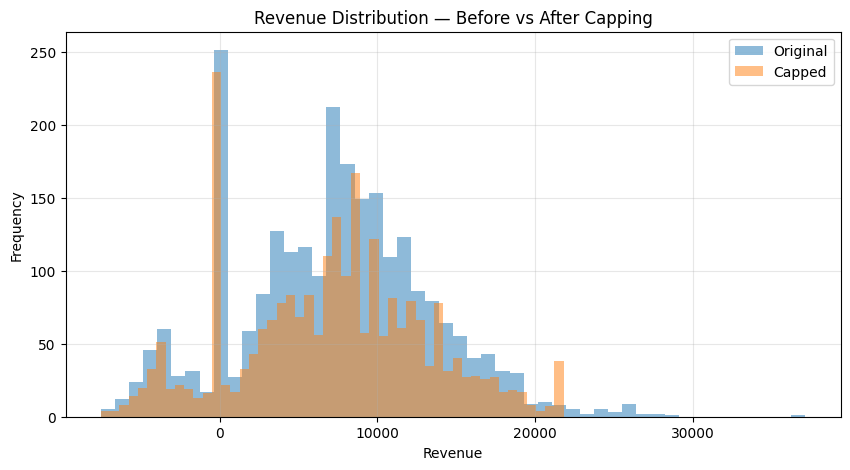

C:\Users\moham\AppData\Local\Temp\ipykernel_18300\2299225361.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


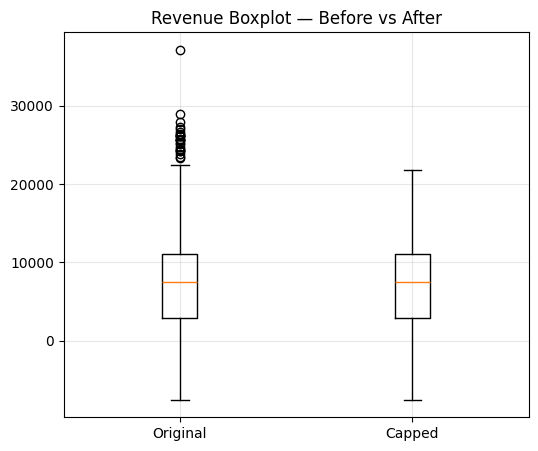

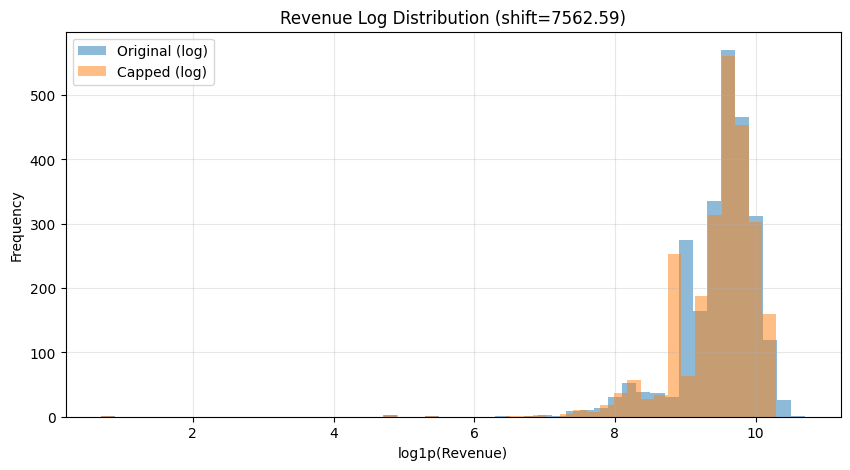

In [58]:
# =========================================
# Revenue — Histogram comparison
# =========================================
plt.figure(figsize=(10, 5))
plt.hist(df_clean["Revenue_final"], bins=50, alpha=0.5, label="Original")
plt.hist(df_clean["Revenue_final_Capped"], bins=50, alpha=0.5, label="Capped")
plt.title("Revenue Distribution — Before vs After Capping")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# =========================================
# Revenue — Boxplot comparison
# =========================================
plt.figure(figsize=(6, 5))
plt.boxplot(
    [df_clean["Revenue_final"], df_clean["Revenue_final_Capped"]],
    labels=["Original", "Capped"],
    showfliers=True
)
plt.title("Revenue Boxplot — Before vs After")
plt.grid(True, alpha=0.3)
plt.show()


# =========================================
# Revenue — Log-scale view (tail inspection)
# =========================================
rev_log_orig, shift_r = safe_log1p(df_clean["Revenue_final"])
rev_log_cap, _ = safe_log1p(df_clean["Revenue_final_Capped"])

plt.figure(figsize=(10, 5))
plt.hist(rev_log_orig, bins=50, alpha=0.5, label="Original (log)")
plt.hist(rev_log_cap, bins=50, alpha=0.5, label="Capped (log)")
plt.title(f"Revenue Log Distribution (shift={shift_r:.2f})")
plt.xlabel("log1p(Revenue)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

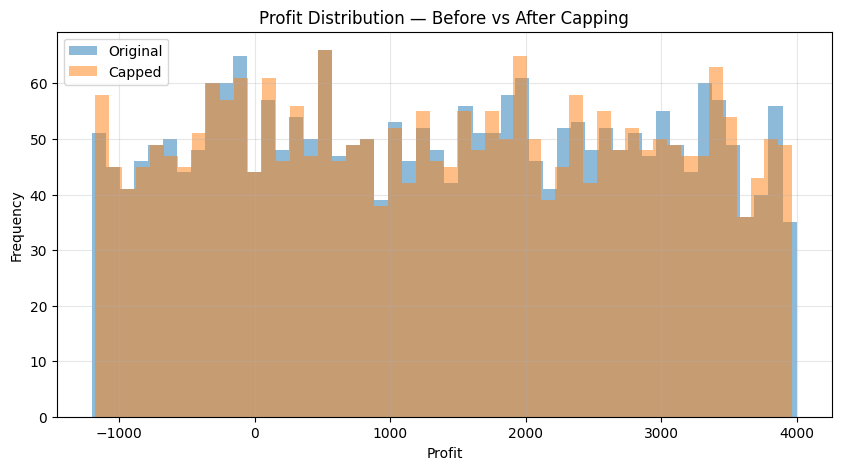

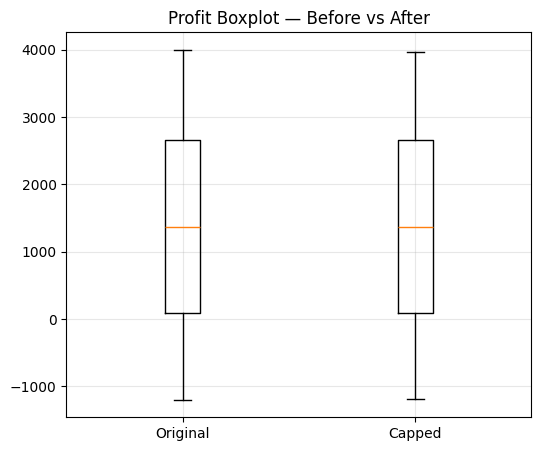

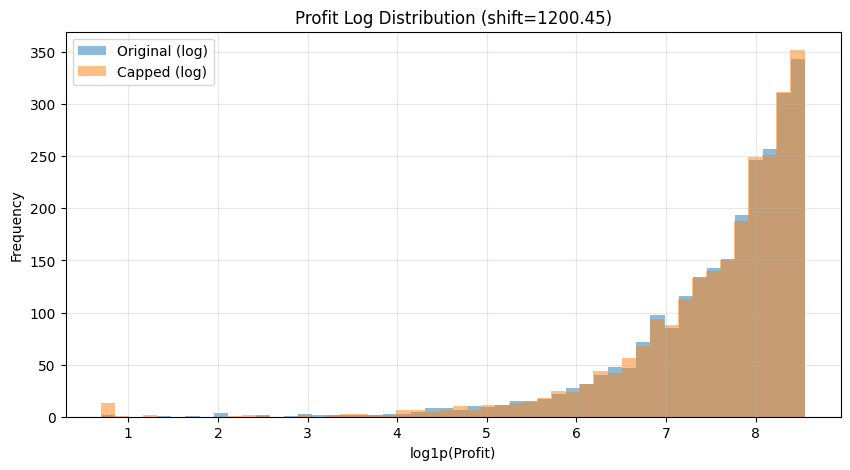

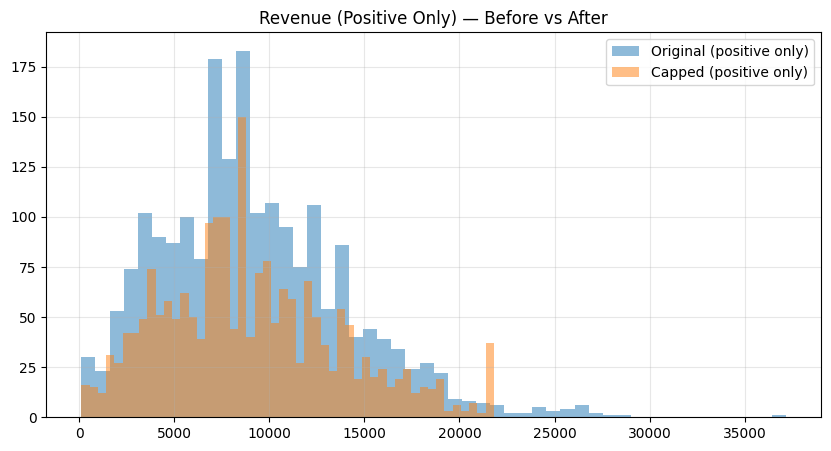


✅ Visual QA complete — inspect tail compression and distribution shape.


In [59]:
# =========================================
# Profit — Histogram comparison
# =========================================
plt.figure(figsize=(10, 5))
plt.hist(df_clean["Profit"], bins=50, alpha=0.5, label="Original")
plt.hist(df_clean["Profit_Capped"], bins=50, alpha=0.5, label="Capped")
plt.title("Profit Distribution — Before vs After Capping")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# =========================================
# Profit — Boxplot comparison
# =========================================
plt.figure(figsize=(6, 5))
plt.boxplot(
    [df_clean["Profit"], df_clean["Profit_Capped"]],
    tick_labels=["Original", "Capped"],
    showfliers=True
)
plt.title("Profit Boxplot — Before vs After")
plt.grid(True, alpha=0.3)
plt.show()


# =========================================
# Profit — Log-scale view
# =========================================
profit_log_orig, shift_p = safe_log1p(df_clean["Profit"])
profit_log_cap, _ = safe_log1p(df_clean["Profit_Capped"])

plt.figure(figsize=(10, 5))
plt.hist(profit_log_orig, bins=50, alpha=0.5, label="Original (log)")
plt.hist(profit_log_cap, bins=50, alpha=0.5, label="Capped (log)")
plt.title(f"Profit Log Distribution (shift={shift_p:.2f})")
plt.xlabel("log1p(Profit)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


plt.figure(figsize=(10,5))
pos = df_clean[df_clean["Revenue_final"] > 0]["Revenue_final"]
pos_c = df_clean[df_clean["Revenue_final_Capped"] > 0]["Revenue_final_Capped"]

plt.hist(pos, bins=50, alpha=0.5, label="Original (positive only)")
plt.hist(pos_c, bins=50, alpha=0.5, label="Capped (positive only)")
plt.title("Revenue (Positive Only) — Before vs After")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("\n✅ Visual QA complete — inspect tail compression and distribution shape.")

### ✅ Outlier Handling Complete
- Revenue capped at **25,572.46** (9 rows)
- Profit capped at **[-1,181.55 → 3,967.71]** (26 rows)
- All negative values (returns) preserved intact
- Visual QA confirms distribution shape is maintained


# 8. Data Validation

In this step, the cleaned dataset is validated to ensure structural consistency, completeness of core fields, valid ranges, and successful execution of the cleaning.

The purpose of this step is to confirm that the dataset is ready for export and downstream use.

In [60]:
validation_report = {}

# 1. Core missing values
core_cols = [
    "Order_ID", "Gender_Category", "Product_Line", "Product_Name",
    "Size", "Units_Sold", "MRP", "Discount_Applied",
    "Revenue_final", "Sales_Channel", "Region", "Profit"
]

validation_report["Core_Missing_Values"] = int(df_clean[core_cols].isna().sum().sum())
validation_report["Order_Date_Missing"] = int(df_clean["Order_Date"].isna().sum())

# 2. Invalid discount range
validation_report["Invalid_Discount_Below_0"] = int((df_clean["Discount_Applied"] < 0).sum())
validation_report["Invalid_Discount_Above_1"] = int((df_clean["Discount_Applied"] > 1).sum())

# 3. Negative MRP
validation_report["Negative_or_Zero_MRP"] = int((df_clean["MRP"] <= 0).sum())

# 4. Region uniqueness after normalization
validation_report["Unique_Regions"] = int(df_clean["Region"].nunique())

# 5. Duplicate rows in final data
validation_report["Duplicate_Rows_Final"] = int(df_clean.duplicated().sum())

# 6. Revenue / capped consistency
validation_report["Revenue_Capped_Nulls"] = int(df_clean["Revenue_final_Capped"].isna().sum())
validation_report["Profit_Capped_Nulls"] = int(df_clean["Profit_Capped"].isna().sum())

# 7. Return flag sanity
validation_report["Return_Flag_Count"] = int(df_clean["is_return"].sum())

validation_df = pd.DataFrame.from_dict(validation_report, orient="index", columns=["Value"])

print("✅ Final Validation Report")
display(validation_df)

✅ Final Validation Report


,Value
Core_Missing_Values,0
Order_Date_Missing,616
Invalid_Discount_Below_0,0
Invalid_Discount_Above_1,0
Negative_or_Zero_MRP,0
Unique_Regions,6
Duplicate_Rows_Final,0
Revenue_Capped_Nulls,0
Profit_Capped_Nulls,0
Return_Flag_Count,205


In [61]:
assert df_clean[core_cols].isna().sum().sum() == 0
assert (df_clean["Discount_Applied"] >= 0).all()
assert (df_clean["Discount_Applied"] <= 1).all()
assert (df_clean["MRP"] > 0).all()
assert df_clean.duplicated().sum() == 0

print("✅ All validation checks passed successfully.")

✅ All validation checks passed successfully.


In [62]:
# === Business Logic Validation ===

checks_passed = 0
checks_total = 4

# 1. Return flag consistency — is_return must match Units_Sold < 0
return_consistent = (df_clean["is_return"] == (df_clean["Units_Sold"] < 0)).all()
print(f"{'✅' if return_consistent else '❌'} Return flag matches Units_Sold < 0: {return_consistent}")
checks_passed += int(return_consistent)

# 2. Zero-sales flag consistency — Is_Zero_Sales must match Units_Sold == 0 & MRP > 0
zero_consistent = (
    df_clean["Is_Zero_Sales"] == ((df_clean["Units_Sold"] == 0) & (df_clean["MRP"] > 0))
).all()
print(f"{'✅' if zero_consistent else '❌'} Zero-sales flag matches Units_Sold == 0 & MRP > 0: {zero_consistent}")
checks_passed += int(zero_consistent)

# 3. Revenue_calc spot-check — for rows using calculated revenue
calc_rows = df_clean["Revenue_Used_Calc_Flag"] == True
if calc_rows.sum() > 0:
    expected = (
        df_clean.loc[calc_rows, "Units_Sold"]
        * df_clean.loc[calc_rows, "MRP"]
        * (1 - df_clean.loc[calc_rows, "Discount_Applied"])
    )
    actual = df_clean.loc[calc_rows, "Revenue_final"]
    max_diff = (expected - actual).abs().max()
    rev_consistent = max_diff < 0.01
    print(f"{'✅' if rev_consistent else '❌'} Revenue_calc consistency (max diff = {max_diff:.4f})")
    checks_passed += int(rev_consistent)
else:
    print("⚠️ No Revenue_Used_Calc_Flag rows — skipping Revenue consistency check")
    checks_passed += 1

# 4. Imputed flag sanity — Units_Sold_Imputed_Flag count must match original NaN count
imputed_count = df_clean["Units_Sold_Imputed_Flag"].sum()
raw_nan_count = df_clean["Units_Sold_raw"].isna().sum()
imputed_match = imputed_count == raw_nan_count
print(f"{'✅' if imputed_match else '❌'} Units_Sold_Imputed_Flag count ({imputed_count}) matches raw NaN count ({raw_nan_count})")
checks_passed += int(imputed_match)

print(f"\n✅ Business logic validation: {checks_passed}/{checks_total} checks passed.")


✅ Return flag matches Units_Sold < 0: True
✅ Zero-sales flag matches Units_Sold == 0 & MRP > 0: True
✅ Revenue_calc consistency (max diff = 0.0000)
✅ Units_Sold_Imputed_Flag count (1235) matches raw NaN count (1235)

✅ Business logic validation: 4/4 checks passed.


## Validation Note

The final validation confirmed that all core fields were successfully cleaned and completed, with the exception of `Order_Date`, which was intentionally preserved as missing where reliable reconstruction was not possible.

All discount values fall within the valid range, no duplicate rows remain, and the final cleaned dataset is structurally ready for export.

## Missing Data Visualization — AFTER Cleaning

<Figure size 1200x600 with 0 Axes>

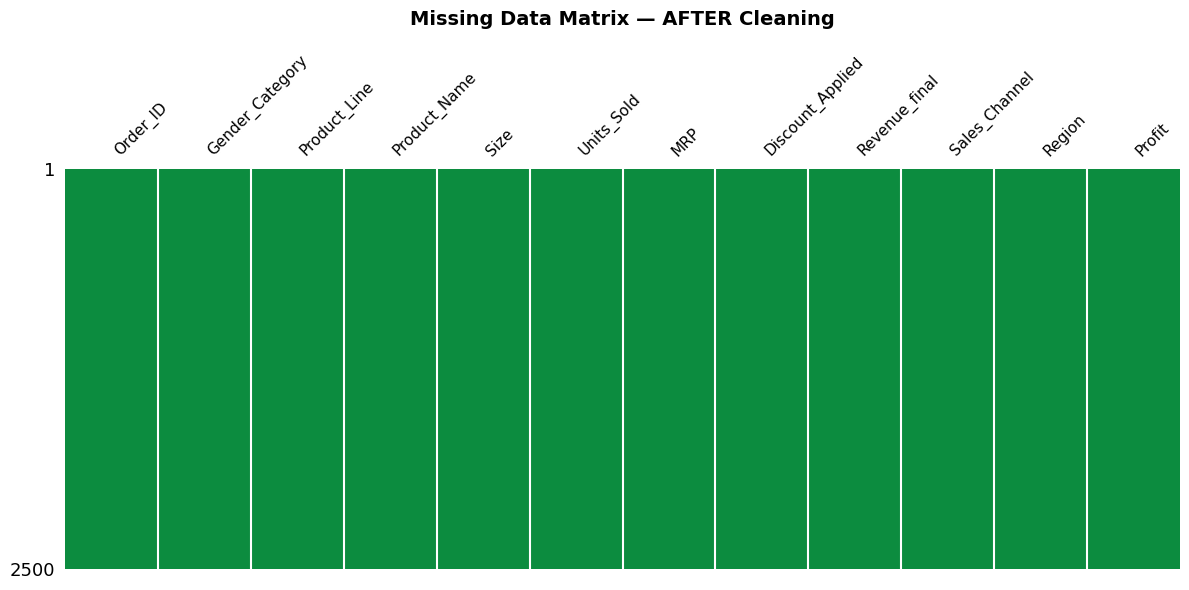

In [63]:
plt.figure(figsize=(12, 6))
msno.matrix(df_clean[core_cols], figsize=(12, 6), fontsize=11, sparkline=False, color=(0.05, 0.55, 0.25))
plt.title("Missing Data Matrix — AFTER Cleaning", fontsize=14, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()


## 9. Save Clean Data

In this final step, the cleaned dataset is exported into two versions:
- **Cleaned Final**: compact dataset for downstream analysis and modeling
- **Audit Full**: complete dataset with raw snapshots, flags, and all derived columns

This ensures both usability and full traceability.


In [64]:
# --- Define final columns for the clean export
final_cols = [
    "Order_ID", "Gender_Category", "Product_Line", "Product_Name",
    "Size", "Units_Sold", "MRP", "Discount_Applied",
    "Revenue_final", "Revenue_final_Capped",
    "Order_Date", "Sales_Channel", "Region",
    "Profit", "Profit_Capped",
    "is_return", "Is_Zero_Sales", "Units_Sold_Imputed_Flag",
    "Date_Missing_Flag",
    "Revenue_Outlier_Flag", "Profit_Outlier_Flag", "Profit_Ratio_Flag"
]


df_final = df_clean[final_cols].copy()

# --- Rename for cleaner column names
df_final = df_final.rename(columns={
    "Revenue_final": "Revenue",
    "Revenue_final_Capped": "Revenue_Capped"
})

# --- Export
os.makedirs("Output", exist_ok=True)
df_final.to_csv("Output/Nike_Sales_Cleaned_Final.csv", index=False)
df_clean.to_csv("Output/Nike_Sales_Audit_Full.csv", index=False)

# --- Summary
print("✅ Files saved successfully:")
print(f"   - Output/Nike_Sales_Cleaned_Final.csv → {df_final.shape}")
print(f"   - Output/Nike_Sales_Audit_Full.csv   → {df_clean.shape}")


✅ Files saved successfully:
   - Output/Nike_Sales_Cleaned_Final.csv → (2500, 22)
   - Output/Nike_Sales_Audit_Full.csv   → (2500, 38)
